<a href="https://colab.research.google.com/github/fredd-a/Intro-to-AI-Project/blob/main/notebooks/02_baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#2.0 Setup & Loading Cleaned Data

---

In [2]:
# Import neccesary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load cleaned data from github or local, "Intro-to-AI-Project/data/processed"
local_path = "../data/processed/student-mat_cleaned.csv"
github_url = "https://raw.githubusercontent.com/fredd-a/Intro-to-AI-Project/main/data/processed/student-mat_cleaned.csv"

if os.path.exists(local_path):
    df = pd.read_csv(local_path)
else:
    df = pd.read_csv(github_url)

# Verify that the cleaned dataset loaded successfully
print("Dataset shape:", df.shape)

# View first rows
df.head(10)

Dataset shape: (395, 39)


,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,18,1,0,0,4,4,2,2,0,...,False,False,False,False,True,False,False,False,True,False
1,0,17,1,0,1,1,1,1,2,0,...,False,False,True,False,False,False,False,False,False,False
2,0,15,1,1,1,1,1,1,2,3,...,False,False,True,False,False,False,True,False,True,False
3,0,15,1,0,1,4,2,1,3,0,...,False,False,False,True,False,True,False,False,True,False
4,0,16,1,0,1,3,3,1,2,0,...,False,False,True,False,False,True,False,False,False,False
5,1,16,1,1,1,4,3,1,2,0,...,False,False,True,False,False,False,False,True,True,False
6,1,16,1,1,1,2,2,1,2,0,...,False,False,True,False,False,True,False,False,True,False
7,0,17,1,0,0,4,4,2,2,0,...,False,False,False,False,True,True,False,False,True,False
8,1,15,1,1,0,3,2,1,2,0,...,False,False,True,False,False,True,False,False,True,False
9,1,15,1,0,1,3,4,1,2,0,...,False,False,True,False,False,True,False,False,True,False


#2.1 Defining Risk Categories

---



In [3]:
df["G3"].describe()

,G3
count,395.000000
mean,10.415190
std,4.581443
min,0.000000
25%,8.000000
50%,11.000000
75%,14.000000
max,20.000000


Compared to the previous dataset, the grading convention puts 75% at 14 so we use this threshold instead.

## Creating Risk Categories

The G3 variable is converted into three classes:

- High Risk: Grade below 10
- Medium Risk: Grade between 10 and 14
- Low Risk: Grade 15 and above

These categories allow us to treat the problem as a classification task.

In [4]:
# Implement the classification targets from final grade (low,medium,high risk)
def classify_risk(grade):
    if grade < 10:
        return "High Risk"
    elif grade < 14:
        return "Medium Risk"
    else:
        return "Low Risk"


df["RiskCategory"] = df["G3"].apply(classify_risk)
df[["G3", "RiskCategory"]].head()

,G3,RiskCategory
0,6,High Risk
1,6,High Risk
2,10,Medium Risk
3,15,Low Risk
4,10,Medium Risk


In [5]:
# Examine the distribution of the target classes before training
df["RiskCategory"].value_counts()


,count
RiskCategory,
Medium Risk,165
High Risk,130
Low Risk,100


In [6]:
df["RiskCategory"].value_counts(normalize=True)*100

,proportion
RiskCategory,
Medium Risk,41.772152
High Risk,32.911392
Low Risk,25.316456


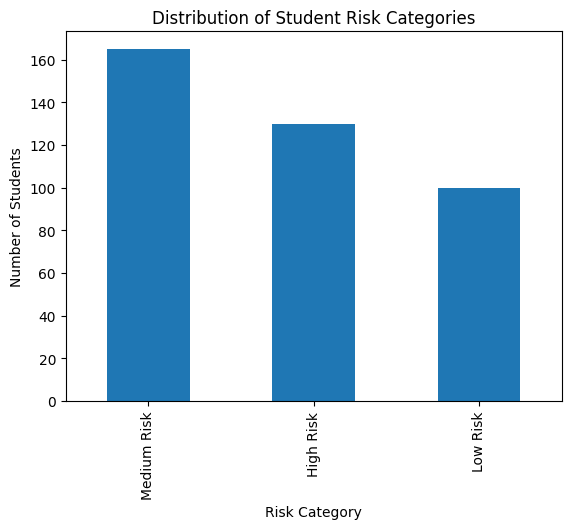

In [7]:
df["RiskCategory"].value_counts().plot(
    kind="bar",
    xlabel="Risk Category",
    ylabel="Number of Students",
    title="Distribution of Student Risk Categories"
)

plt.show()

The target variable was created from FinalGrade by grouping students into three academic risk categories. Students with grades below 75 were classified as High Risk, grades between 75 and 84 as Medium Risk, and grades of 85 or above as Low Risk. These thresholds were selected based on the dataset distribution, where the minimum grade was 62 and the median grade was 80. This ensures that all three categories contain sufficient examples for classification.

# 2.2 Feature Selection & Encoding

---



In [8]:
# Inspect the dataset before feature selection and encoding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 40 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   sex                395 non-null    int64 
 1   age                395 non-null    int64 
 2   address            395 non-null    int64 
 3   famsize            395 non-null    int64 
 4   Pstatus            395 non-null    int64 
 5   Medu               395 non-null    int64 
 6   Fedu               395 non-null    int64 
 7   traveltime         395 non-null    int64 
 8   studytime          395 non-null    int64 
 9   failures           395 non-null    int64 
 10  schoolsup          395 non-null    int64 
 11  famsup             395 non-null    int64 
 12  paid               395 non-null    int64 
 13  activities         395 non-null    int64 
 14  nursery            395 non-null    int64 
 15  higher             395 non-null    int64 
 16  internet           395 non-null    int64 
 1

# Separate predictor variables (X) from the target variable (y)

In [9]:

# Separate input features and prediction target

X = df.drop(columns=["G3", "RiskCategory"])
y = df["RiskCategory"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head(10))

Features:


,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,18,1,0,0,4,4,2,2,0,...,False,False,False,False,True,False,False,False,True,False
1,0,17,1,0,1,1,1,1,2,0,...,False,False,True,False,False,False,False,False,False,False
2,0,15,1,1,1,1,1,1,2,3,...,False,False,True,False,False,False,True,False,True,False
3,0,15,1,0,1,4,2,1,3,0,...,False,False,False,True,False,True,False,False,True,False
4,0,16,1,0,1,3,3,1,2,0,...,False,False,True,False,False,True,False,False,False,False



Target:


,RiskCategory
0,High Risk
1,High Risk
2,Medium Risk
3,Low Risk
4,Medium Risk
5,Low Risk
6,Medium Risk
7,High Risk
8,Low Risk
9,Low Risk


# Verify that all categorical features have been encoded correctly (from 01_eda_cleaning)

In [10]:
X.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,18,1,0,0,4,4,2,2,0,...,False,False,False,False,True,False,False,False,True,False
1,0,17,1,0,1,1,1,1,2,0,...,False,False,True,False,False,False,False,False,False,False
2,0,15,1,1,1,1,1,1,2,3,...,False,False,True,False,False,False,True,False,True,False
3,0,15,1,0,1,4,2,1,3,0,...,False,False,False,True,False,True,False,False,True,False
4,0,16,1,0,1,3,3,1,2,0,...,False,False,True,False,False,True,False,False,False,False


At this stage, the dataset has been cleaned, the target variable has been defined, categorical variables have been encoded, and the feature matrix is ready for model training. The next step is to split the data into training and testing sets.

#2.3 Train/Test Split

---



# Inspect the dataset before spliting

In [11]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   sex                395 non-null    int64
 1   age                395 non-null    int64
 2   address            395 non-null    int64
 3   famsize            395 non-null    int64
 4   Pstatus            395 non-null    int64
 5   Medu               395 non-null    int64
 6   Fedu               395 non-null    int64
 7   traveltime         395 non-null    int64
 8   studytime          395 non-null    int64
 9   failures           395 non-null    int64
 10  schoolsup          395 non-null    int64
 11  famsup             395 non-null    int64
 12  paid               395 non-null    int64
 13  activities         395 non-null    int64
 14  nursery            395 non-null    int64
 15  higher             395 non-null    int64
 16  internet           395 non-null    int64
 17  romantic        

#Perform the stratified split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#Checking the sizes

In [13]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (316, 38)
X_test shape: (79, 38)
y_train shape: (316,)
y_test shape: (79,)


#Confirming class balance

In [14]:
print("Original Dataset:")
print(y.value_counts(normalize=True) * 100)

Original Dataset:
RiskCategory
Medium Risk    41.772152
High Risk      32.911392
Low Risk       25.316456
Name: proportion, dtype: float64


#Check training set:

In [15]:
print("\nTraining Set:")
print(y_train.value_counts(normalize=True) * 100)


Training Set:
RiskCategory
Medium Risk    41.772152
High Risk      32.911392
Low Risk       25.316456
Name: proportion, dtype: float64


#Check testing set:

In [16]:
print("\nTesting Set:")
print(y_test.value_counts(normalize=True) * 100)


Testing Set:
RiskCategory
Medium Risk    41.772152
High Risk      32.911392
Low Risk       25.316456
Name: proportion, dtype: float64


### Train/Test Split

The dataset was divided into training and testing sets using an 80/20 split. Since the target variable contains multiple risk categories, stratified sampling was applied to preserve the proportion of High Risk, Medium Risk, and Low Risk students in both sets.

This prevents class imbalance between training and testing data and ensures that the model evaluation represents the original dataset distribution.

In [ ]:
# Stratified split (since it's classification) on the risk-category target.
# Print resulting sizes and confirm class balance is preserved in both sets.

#2.4 Baseline Comparator

---



In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# A dumb baseline (e.g. always predict the majority class)
dumb_base = DummyClassifier(strategy="most_frequent", random_state = 42)

# Fit the dumb baseline on the training data
dumb_base.fit(X_train, y_train)

# Establishes the floor Random Forest needs to beat.
base_pred = dumb_base.predict(X_test)
base_acc = accuracy_score(y_test, base_pred)

# Report its accuracy.
print("Baseline Accuracy:", base_acc)

Baseline Accuracy: 0.4177215189873418


#2.5 Random Forest Classifier (Main Model)

---



In [23]:
from sklearn.ensemble import RandomForestClassifier
# Fit RandomForestClassifier with random_state set and modest constraints (max_depth,min_samples_leaf) given the dataset size
randomf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
    )
randomf_clf.fit(X_train, y_train)

# Print basic fit confirmation
print("Train Accuracy: ", randomf_clf.score(X_train, y_train))
print("Test Accuracy: ", randomf_clf.score(X_test, y_test))

Train Accuracy:  0.7753164556962026
Test Accuracy:  0.46835443037974683


This Random Forest Classifier was trained using 200 trees to ensure a stabe and average prediction.

Two constraints(max_dept = 6, min_samples_leaf = 5) were used to prevent overfitting, given the size of the dataset.
These constraints were applied because after testing with an unconstrained version, train accuracy was 99% while test accuracy was 39%, showing that it was fitting noise.

The constrainted model has a train accuracy of 53% and test accuracy of 47%, indicating there is no overfitting, but its overall accuracy is still limited by weak signal in the underlying features.

In [25]:
randomf_clf_v2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=3,           # reduced from 6
    min_samples_leaf=20,   # increased from 5
    random_state=42
)
randomf_clf_v2.fit(X_train, y_train)
print("Train Accuracy:", randomf_clf_v2.score(X_train, y_train))
print("Test Accuracy:", randomf_clf_v2.score(X_test, y_test))

Train Accuracy: 0.5379746835443038
Test Accuracy: 0.4936708860759494


After testing several combinations of max_depth and min_samples_leaf to address overfitting, the combination of 3 and 20 produced the smallest train/test gap and the highest accuracy at 0.4936.

We will be adopting max_depth = 3 and min_samples_leaf = 20 for our final model.

#2.6 Evaluating the Classifier

---



Accuracy: 0.46835443037974683
              precision    recall  f1-score   support

   High Risk       0.47      0.31      0.37        26
    Low Risk       0.62      0.40      0.48        20
 Medium Risk       0.43      0.64      0.51        33

    accuracy                           0.47        79
   macro avg       0.50      0.45      0.46        79
weighted avg       0.49      0.47      0.46        79



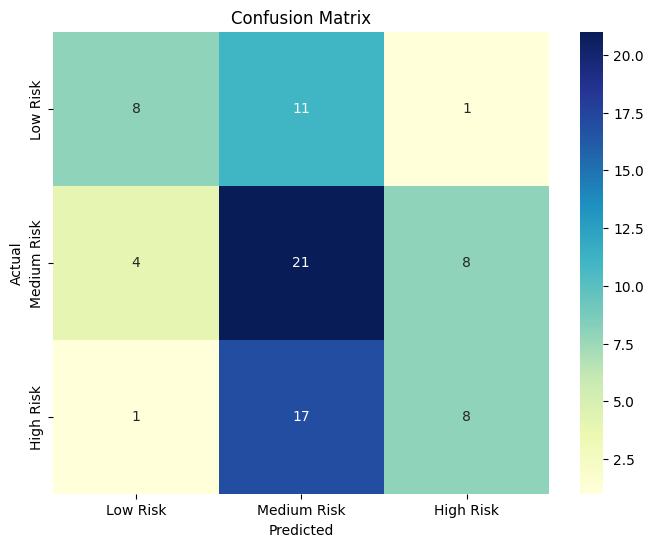

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = randomf_clf.predict(X_test)

# Accuracy, precision/recall/F1 (per class)
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print(classification_report(y_test, y_pred))

# Confusion Matrix
labels = ["Low Risk", "Medium Risk", "High Risk"]
conf_matrix = confusion_matrix(y_test, y_pred, labels=labels)

fig,ax = plt.subplots(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
ax.set_title("Confusion Matrix")
plt.show()

**Why Precission/Recall Matter More Than Accuracy**

**Old Dataset**

Overall accuracy (47%) looks reasonable at first glance, but the per-class breakdown reveals a critical failure: High Risk recall is only 0.02, meaning the model correctly identified just 1 of 55 truly high-risk students in the test set, with Medium Risk recall equally low at 0.02, while Low Risk recall sits at 0.98.

The model is essentially predicting "Low Risk" for almost every student regardless of their actual attendance, study habits, or prior grades.

**New Dataset**

Here, High Risk recall is 0.31 (catching 8 of 26 truly high-risk students in the test set) and Medium Risk recall is 0.64 — both substantially above the almost zero recall seen with the previous dataset.

Precision for High Risk (0.47) indicates that when the model does flag a student as High Risk, it is correct less than half the time.

High Risk prediction is the most important metric to optimize going forward, since missing a truly at-risk student is more costly than  flagging a student who is not at risk. 0.31 recall leaves room for improvement, which we address in Week 12.


#2.7 Feature Importance (Classifier)

---



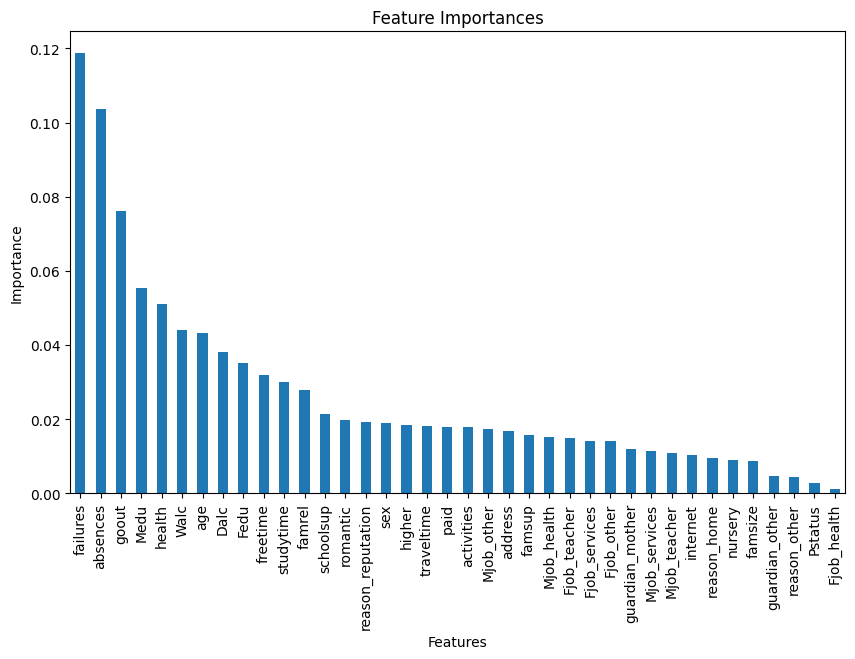

In [28]:
import pandas as pd
# Plot importances
importances = pd.Series(randomf_clf.feature_importances_, index=X_train.columns)

# Sort the importances in descending order
importances = importances.sort_values(ascending=False)

# Plot the feature importances
fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='bar', figsize=(10, 6))
ax.set_xlabel('Features')
ax.set_ylabel('Importance')
ax.set_title('Feature Importances')

plt.show()
# Reasoning cell interpreting results — flag PreviousGrade dominance if it appears

# Note where Online Classes Taken lands relative to your EDA finding.
# (Explanation) During the data cleaning I found that for 'OnlineClassesTaken' there was no difference in
# final grade between those marked true and those marked false, how does what I found compare with what you find here.

`absences` ranks as the second most important
feature here, despite showing a near-zero linear correlation with G3
(r = 0.034) in our earlier EDA. Feature importance shows how useful a variable is for splitting the data across many decision points,including non-linear relationships and interactions with other features. `absences` may matter differently depending on a student's `failures` or `study time`, whereas a simple correlation coefficient only captures a straight-line relationship.

`failures` (0.119) and `absences` (0.104) are identified as
the two most influential features, followed by `goout` (0.076), `Medu` (0.056), and `health` (0.051). This aligns well with educational research: prior course failures and absenteeism are commonly strong predictors of academic outcomes, and the model recognizes that.

#2.8 Summary & Next Steps
---

In [ ]:
# Markdown cell tying it together: baseline vs Random Forest comparison, key findings
# What's due for Week 12